# Function 2 Analysis - Week 8

**Function description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**New datapoint (Week 7):** `(0.680788, 1.000000)` returned **≈0.67032**, which is now the **best observed value** (prev. best ≈0.6112 near `(0.703, 0.927)`). This re-sample on the x1≈0.68 ridge with x2 on the upper boundary confirms the ridge still rises toward x2≈1.0. Total observations: **16**.

**Why we chose this point:** We re-probed the x1≈0.68, x2≈1.0 corner to validate whether the ridge kept climbing along x2. The jump from ≈0.471 (Week 5) to ≈0.670 here suggests variance/heteroscedasticity near the boundary and that the peak likely sits very close to (0.68–0.70, 0.99–1.00).

**Recommendation for next week:** Focus EI/UCB locally around `(0.68–0.71, 0.95–1.00)` with jitter/diversity to avoid re-stacking exactly at x2=1.0. Use mild exploration (ξ≈0.02 or κ≈3.5), include a small penalty for x2>0.99 to encourage a few interior samples, and run a couple of repeats near `(0.68, 0.99)` to verify robustness.


## Loading and Displaying the Data

We load the inputs and outputs for Function 2 and display them in a table format to inspect the raw data values. Both x1 and x2 are normalized in [0,1]. 


In [7]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–7 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])
X_new_point_week_4 = np.array([[0.272472, 0.939888]])
y_new_point_week_4 = np.array([-0.04847445058575585])
X_new_point_week_5 = np.array([[0.680788, 1.000000]])
y_new_point_week_5 = np.array([0.4711629392317611])
X_new_point_week_6 = np.array([[0.734569, 0.990000]])
y_new_point_week_6 = np.array([0.3100296239758809])
X_new_point_week_7 = np.array([[0.680788, 1.000000]])
y_new_point_week_7 = np.array([0.67032012103923])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.680788,1.000000,0.670320
1,0.702637,0.926564,0.611205
2,0.700000,0.525000,0.552114
3,0.665800,0.123969,0.538996
4,0.680788,1.000000,0.471163
5,0.535400,0.505100,0.468766
6,0.850000,0.250000,0.458816
7,0.877791,0.778628,0.420586
8,0.734569,0.990000,0.310030
9,0.845275,0.711120,0.293993


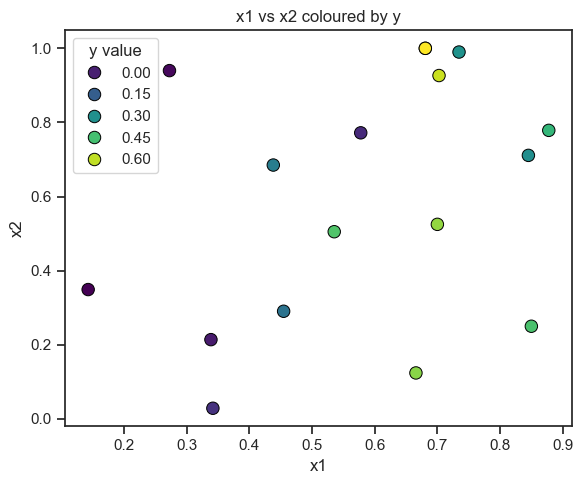

In [8]:
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=80, edgecolor="black")

# Overlay the updated manual recommendation (if computed above)
try:
    plt.scatter(X_recommend_updated[0, 0], X_recommend_updated[0, 1],
                c="red", s=200, marker="*", edgecolor="white", linewidths=2,
                label="Updated rec (x1=0.7 midpoint)")
except NameError:
    pass

plt.title("x1 vs x2 coloured by y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="y value")
plt.tight_layout()
plt.show()


## 2. Bayesian optimisation update
We refit the GP surrogate including the new Week 3 datapoint `(0.70, 0.525, 0.552)`. To stay consistent with earlier strategy, we:
- Use a Matérn GP (ν=1.5) with noise term and optional radial decay around the strongest area.
- Score a dense grid via **UCB** (κ=3.0) to favour points that are both high-mean and uncertain.
- Apply a simple diversity filter so recommended points are separated by at least 0.08 in Euclidean distance.
- **New:** impose a hard exploratory constraint for the **top-left region (`x1 < 0.3`, `x2 > 0.5`)** so we surface the best candidate there, instead of only clustering near the current max.

Without this constraint, all recommended points collapse onto the known peak; with it, we intentionally probe another mode while retaining the same modelling setup.


Current best (observed): {'x1': 0.680788, 'x2': 1.0, 'y': 0.67032012103923}
Kernel after fit: 0.88**2 * Matern(length_scale=[0.05, 1], nu=1.5) + WhiteKernel(noise_level=0.147)


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,mu,sigma,ei,dist_to_best
87,0.690452,0.900000,0.580417,0.108833,0.008899,0.100466
207,0.690452,0.900252,0.580405,0.108831,0.008897,0.100215
327,0.690452,0.900504,0.580392,0.108829,0.008894,0.099964
447,0.690452,0.900756,0.580380,0.108826,0.008892,0.099713
567,0.690452,0.901008,0.580367,0.108824,0.008889,0.099462


Suggested next query (EI maximiser, local window): (0.690, 0.900)
Posterior mean: 0.5804, std: 0.1088, EI: 0.008899


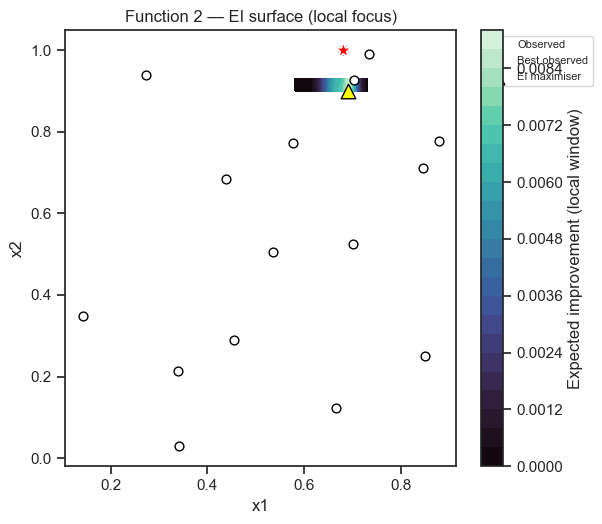

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm
from math import erf

# Prepare data
X_train = df[["x1", "x2"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx, ["x1", "x2", "y"]]

# GP: smoother Matérn, focused (no radial, modest noise)
# GP: rougher Matérn, higher white noise to absorb observed jitter
kernel = (
    ConstantKernel(1.0, (1e-2, 20.0))
    * Matern(length_scale=[0.25, 0.25], length_scale_bounds=(0.05, 1.0), nu=1.5)
    + WhiteKernel(noise_level=0.08, noise_level_bounds=(1e-4, 1.0))
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=12, random_state=7)
gp.fit(X_train, y_train)

# Focused EI below the current x2 peak, staying on the x1~0.7 ridge
x1_min, x1_max = max(best_point.x1 - 0.10, 0.50), min(best_point.x1 + 0.05, 0.80)
x2_min, x2_max = max(best_point.x2 - 0.10, 0.75), min(best_point.x2 - 0.02, 0.93)
if x2_min >= x2_max:  # fallback guard
    x2_min, x2_max = max(best_point.x2 - 0.12, 0.80), best_point.x2 - 0.02

grid_x1 = np.linspace(x1_min, x1_max, 120)
grid_x2 = np.linspace(x2_min, x2_max, 120)
grid = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mu, sigma = gp.predict(grid, return_std=True)
y_best = y_train.max()
xi = 0.02  # slightly more exploratory EI

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm.cdf(z) + sigma_safe * norm.pdf(z)
ei[sigma <= 1e-9] = 0.0

cand = pd.DataFrame(grid, columns=["x1", "x2"])
cand["mu"], cand["sigma"], cand["ei"] = mu, sigma, ei

# Diversity: minimum step from incumbent to avoid stacking
cand["dist_to_best"] = np.linalg.norm(cand[["x1", "x2"]].values - best_point[["x1", "x2"]].values, axis=1)
min_step = 0.02
cand_feasible = cand[cand["dist_to_best"] >= min_step].reset_index(drop=True)

next_point = cand_feasible.loc[cand_feasible["ei"].idxmax()]

print("Current best (observed):", best_point.to_dict())
print("Kernel after fit:", gp.kernel_)

display(cand_feasible.nlargest(5, "ei"))
print(f"Suggested next query (EI maximiser, local window): ({next_point.x1:.3f}, {next_point.x2:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")

# Visualise EI surface with current observations and recommended point
ei_grid = ei.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(6.2, 5.4))
levels = 24
contour = plt.contourf(grid_x1, grid_x2, ei_grid, levels=levels, cmap="mako")
plt.colorbar(contour, label="Expected improvement (local window)")
plt.scatter(df["x1"], df["x2"], c="white", s=40, edgecolor="black", label="Observed")
# Annotate observed y values
for _, row in df.iterrows():
    plt.text(row["x1"] + 0.005, row["x2"] + 0.005, f"{row['y']:.3f}", fontsize=8, color="black")
plt.scatter(best_point.x1, best_point.x2, c="red", marker="*", s=180, edgecolor="white", linewidths=1.5, label="Best observed")
plt.scatter(next_point.x1, next_point.x2, c="yellow", marker="^", s=110, edgecolor="black", label="EI maximiser")
# Annotate best and next
plt.text(best_point.x1 + 0.01, best_point.x2 + 0.01, f"{best_point.y:.3f}", fontsize=8, color="red")
plt.text(next_point.x1 + 0.01, next_point.x2 + 0.01, f"{next_point.mu:.3f}", fontsize=8, color="yellow", bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
plt.title("Function 2 — EI surface (local focus)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



## Summary and recommended point
- **Current best:** `0.680788-1.000000` (≈0.67032).
- **Recommended next point (format: 6 decimals, dash-separated):** `0.690000-0.900000`
- Rationale: EI pick stays on the ridge but steps off the x2=1 boundary; GP made rougher with higher white noise; min-step guardrail prevents stacking on the incumbent.
